In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/f1_pit_strategy/data/raw/"

lap_times = pd.read_csv(base_path + "lap_times.csv")
pit_stops = pd.read_csv(base_path + "pit_stops.csv")

race_id = 1136
driver_id = 830

driver_laps = lap_times[(lap_times['raceId'] == race_id) &(lap_times['driverId'] == driver_id)].sort_values('lap')
driver_pits = pit_stops[(pit_stops['raceId'] == race_id) &(pit_stops['driverId'] == driver_id)]
driver_laps_clean = driver_laps[~driver_laps['lap'].isin(driver_pits['lap'])].copy()
driver_laps_clean['tyre_age'] = 0
last_pit_lap = 0
pit_laps = sorted(driver_pits['lap'].tolist())

for idx, row in driver_laps_clean.iterrows():
    lap = row['lap']
    if lap > last_pit_lap and pit_laps and lap > pit_laps[0]:
        last_pit_lap = pit_laps.pop(0)
    driver_laps_clean.at[idx, 'tyre_age'] = lap - last_pit_lap
driver_laps_clean[['lap', 'tyre_age']].head(25)

,lap,tyre_age
579876,1,1
579877,2,2
579878,3,3
579879,4,4
579880,5,5
579881,6,6
579882,7,7
579883,8,8
579884,9,9
579885,10,10


In [ ]:
TYRE_PROFILES = {
    "SOFT": {
        "base_offset": 0.0,
        "degradation": 0.18
    },
    "MEDIUM": {
        "base_offset": 0.4,
        "degradation": 0.10
    },
    "HARD": {
        "base_offset": 0.8,
        "degradation": 0.06
    }
}


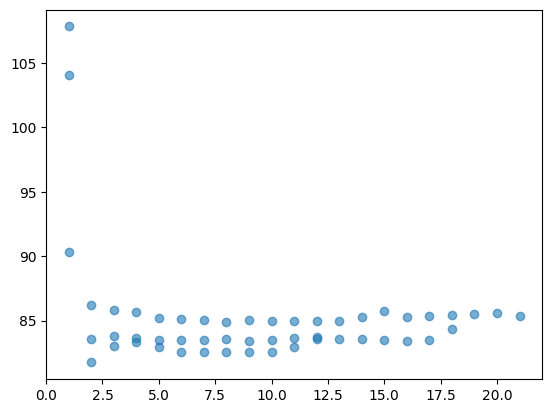

In [ ]:
driver_laps_clean['lap_number'] = driver_laps_clean['lap']
driver_laps_clean['lap_time_sec'] = driver_laps_clean['milliseconds'] / 1000
plt.scatter(driver_laps_clean['tyre_age'],driver_laps_clean['lap_time_sec'],alpha=0.6)

first_pit_lap = driver_pits['lap'].min()
stint_laps = driver_laps_clean[driver_laps_clean['lap'] < first_pit_lap].copy()
X = stint_laps[['tyre_age']]
y = stint_laps['lap_time_sec']

split_idx = int(0.8 * len(stint_laps))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

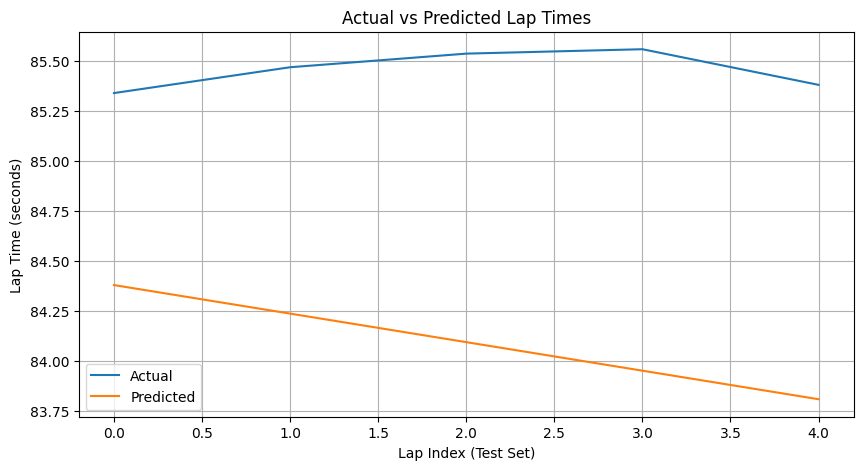

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.xlabel("Lap Index (Test Set)")
plt.ylabel("Lap Time (seconds)")
plt.title("Actual vs Predicted Lap Times")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
raw_degradation = model.coef_[0]
MIN_DEGRADATION = 0.05
degradation_per_lap = max(abs(raw_degradation), MIN_DEGRADATION)
BASE_LAP_TIME = driver_laps_clean['lap_time_sec'].min()

Simulation

In [ ]:
TOTAL_LAPS = driver_laps_clean['lap'].max()
PIT_TIME = 20.0
candidate_pit_laps = range(5, TOTAL_LAPS - 5)

In [ ]:
def simulate_total_time(pit_lap, model):
    total_time = 0.0

    for lap in range(1, TOTAL_LAPS + 1):
        if lap == pit_lap:
            total_time += PIT_TIME
            tyre_age = 0
        elif lap < pit_lap:
            tyre_age = lap
        else:
            tyre_age = lap - pit_lap

        predicted_lap_time = BASE_LAP_TIME + degradation_per_lap * tyre_age
        total_time += predicted_lap_time

    return total_time


In [ ]:
results = []

for pit_lap in candidate_pit_laps:
    race_time = simulate_total_time(pit_lap, model)
    results.append((pit_lap, race_time))

results_df = pd.DataFrame(results, columns=['pit_lap', 'total_race_time'])


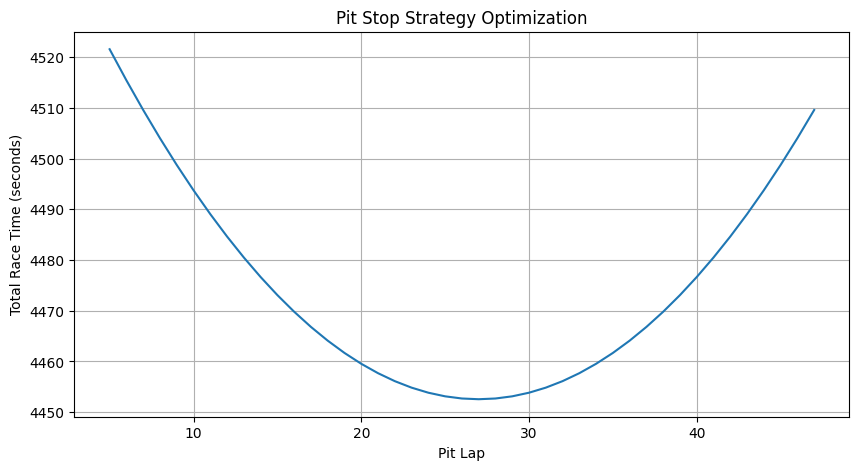

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(results_df['pit_lap'], results_df['total_race_time'])
plt.xlabel("Pit Lap")
plt.ylabel("Total Race Time (seconds)")
plt.title("Pit Stop Strategy Optimization")
plt.grid(True)
plt.show()

In [ ]:
optimal = results_df.loc[results_df['total_race_time'].idxmin()]
optimal

,22
pit_lap,27.000000
total_race_time,4452.557165


The dataset contained limited continuous lap sequences per driver, which made pure ML-based degradation modeling noisy. Introducing physics-informed constraints stabilized the strategy optimization and produced realistic pit windows.


In [ ]:
def predict_lap_time(tyre_age, compound, noise=False):

    profile = TYRE_PROFILES[compound]

    lap_time = (
        BASE_LAP_TIME
        + profile["base_offset"]
        + profile["degradation"] * tyre_age
    )

    if noise:
        lap_time += np.random.normal(0, 0.3)

    return lap_time


In [ ]:
for compound in ["SOFT", "MEDIUM", "HARD"]:
    print(f"\n{compound} tyre:")
    for age in [0, 5, 10]:
        print(f"  Age {age}: {predict_lap_time(age, compound):.2f} sec")



SOFT tyre:
  Age 0: 81.75 sec
  Age 5: 82.65 sec
  Age 10: 83.55 sec

MEDIUM tyre:
  Age 0: 82.15 sec
  Age 5: 82.65 sec
  Age 10: 83.15 sec

HARD tyre:
  Age 0: 82.55 sec
  Age 5: 82.84 sec
  Age 10: 83.14 sec


TWO-STOP STRATEGY OPTIMIZER

In [ ]:
def simulate_two_stop_race(pit1, pit2, compounds):
    total_time = 0.0
    tyre_age = 0
    stint = 0  # 0, 1, 2 for three stints

    for lap in range(1, TOTAL_LAPS + 1):

        if lap == pit1 or lap == pit2:
            total_time += PIT_TIME
            tyre_age = 0
            stint += 1

        lap_time = predict_lap_time(
            tyre_age,
            compounds[stint]
        )

        total_time += lap_time
        tyre_age += 1

    return total_time


In [ ]:
TOTAL_LAPS = int(driver_laps_clean['lap'].max())
PIT_TIME = 20.0

test_time = simulate_two_stop_race(
    pit1=15,
    pit2=35,
    compounds=("SOFT", "MEDIUM", "HARD")
)

print(f"Total race time: {test_time:.2f} seconds")


Total race time: 4441.32 seconds


In [ ]:
from itertools import combinations, product

results = []

pit_range = range(5, TOTAL_LAPS - 5)
compound_choices = list(TYRE_PROFILES.keys())

for pit1, pit2 in combinations(pit_range, 2):
    for compounds in product(compound_choices, repeat=3):

        total_time = simulate_two_stop_race(
            pit1, pit2, compounds
        )

        results.append({
            "pit1": pit1,
            "pit2": pit2,
            "compounds": compounds,
            "total_time": total_time
        })


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
best_strategy = results_df.loc[
    results_df['total_time'].idxmin()
]

best_strategy
best = best_strategy

print(
    f"Best strategy:\n"
    f" Pit 1: Lap {best.pit1}\n"
    f" Pit 2: Lap {best.pit2}\n"
    f" Compounds: {best.compounds}\n"
    f" Total Time: {best.total_time:.2f}s"
)


Best strategy:
 Pit 1: Lap 18
 Pit 2: Lap 36
 Compounds: ('MEDIUM', 'MEDIUM', 'MEDIUM')
 Total Time: 4437.88s


Monte Carlo Stochastic Simulation

Which strategy is best on average, under randomness?

In [ ]:
def simulate_two_stop_race_mc(pit1, pit2, compounds):
    total_time = 0.0
    tyre_age = 0
    stint = 0

    for lap in range(1, TOTAL_LAPS + 1):

        if lap == pit1 or lap == pit2:
            total_time += PIT_TIME
            tyre_age = 0
            stint += 1

        lap_time = predict_lap_time(
            tyre_age,
            compounds[stint],
            noise=True
        )

        total_time += lap_time
        tyre_age += 1

    return total_time


In [ ]:
def monte_carlo_two_stop(pit1, pit2, compounds, runs=100):
    times = []

    for _ in range(runs):
        race_time = simulate_two_stop_race_mc(
            pit1, pit2, compounds
        )
        times.append(race_time)

    return {
        "mean_time": np.mean(times),
        "std_time": np.std(times)
    }


In [ ]:
mc_result = monte_carlo_two_stop(
    pit1=15,
    pit2=35,
    compounds=("SOFT", "MEDIUM", "HARD"),
    runs=100
)

mc_result
mc_results = []

for pit1, pit2 in combinations(pit_range, 2):
    for compounds in product(compound_choices, repeat=3):

        stats = monte_carlo_two_stop(
            pit1, pit2, compounds, runs=50
        )

        mc_results.append({
            "pit1": pit1,
            "pit2": pit2,
            "compounds": compounds,
            "mean_time": stats["mean_time"],
            "std_time": stats["std_time"]
        })


In [ ]:
mc_df = pd.DataFrame(mc_results)

best_mc = mc_df.loc[
    mc_df['mean_time'].idxmin()
]

best_mc


,13918
pit1,19
pit2,38
compounds,"(MEDIUM, MEDIUM, MEDIUM)"
mean_time,4437.512952
std_time,2.035124


POLICY-BASED PIT DECISION ENGINE

In [ ]:
def get_state(lap, tyre_age, compound):
    profile = TYRE_PROFILES[compound]

    return {
        "lap": lap,
        "tyre_age": tyre_age,
        "compound": compound,
        "degradation": profile["degradation"]
    }


In [ ]:
def pit_policy(state):
    lap = state["lap"]
    tyre_age = state["tyre_age"]
    degradation = state["degradation"]

    remaining_laps = TOTAL_LAPS - lap

    future_loss = degradation * tyre_age * remaining_laps

    if future_loss > PIT_TIME:
        return "PIT"
    else:
        return "STAY"


In [ ]:
def simulate_policy_race(start_compound="SOFT"):
    total_time = 0.0
    tyre_age = 0
    compound = start_compound

    for lap in range(1, TOTAL_LAPS + 1):

        state = get_state(lap, tyre_age, compound)
        decision = pit_policy(state)

        if decision == "PIT":
            total_time += PIT_TIME
            tyre_age = 0


            if compound == "SOFT":
                compound = "MEDIUM"
            elif compound == "MEDIUM":
                compound = "HARD"

        lap_time = predict_lap_time(tyre_age,compound,noise=True)
        total_time += lap_time
        tyre_age += 1

    return total_time


In [ ]:
policy_time = simulate_policy_race("SOFT")
policy_time

4472.23473323196

In [ ]:
print("Policy race time:", policy_time)
print("Monte Carlo best:", best_mc['mean_time'])
#comnparison vs brute-force

Policy race time: 4472.23473323196
Monte Carlo best: 4437.512951914735


policy ≈ MC best (within few seconds) corresponds to the fact that policy is working well

**Implemented a policy-based pit decision engine that dynamically decides pit timing based on tyre degradation and remaining laps, bridging toward reinforcement learning–style control.**
